# О чём пишут выпускные работы: темы ВКР в российских вузах

Количественное исследование **2251 темы** выпускных квалификационных работ по восьми укрупнённым группам специальностей (УГСН).
Данные собраны 30 сентября 2026 года из открытых репозиториев пяти вузов.

**Цель.** Выяснить, какие темы ВКР выбирают студенты, и сравнить группы специальностей между собой.

**Задачи**
1. Собрать не меньше 150 тем на каждую УГСН из открытых источников, где у работы указано направление подготовки.
2. Очистить названия и привести слова к начальной форме.
3. Найти самые частые слова и словосочетания, отделив «рамочные» слова (анализ, разработка) от предметных.
4. Выделить организации, которые студенты называют в темах, и сквозные тематические линии.
5. Оценить, насколько работы прикладные.

**Стек:** pandas, pymorphy3, matplotlib.

| Вуз | Источник | УГСН |
|---|---|---|
| НИУ ВШЭ | [hse.ru/edu/vkr](https://www.hse.ru/edu/vkr/) | 09, 37, 38, 40, 42, 45 |
| СПбГУ | [dspace.spbu.ru](https://dspace.spbu.ru/), сообщество Graduation projects | 37, 38, 40, 45 |
| Сибирский федеральный университет | [elib.sfu-kras.ru](https://elib.sfu-kras.ru/handle/2311/26348) | 09, 20, 42, 44 |
| Томский политехнический университет | [earchive.tpu.ru](https://earchive.tpu.ru/handle/11683/173) | 09, 20, 38, 45 |
| КГПУ им. В. П. Астафьева | [elib.kspu.ru](https://elib.kspu.ru/graduation-work) | 44 |

## 1. Импорт и настройки

In [1]:
import re
import collections
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pymorphy3

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

# палитра: одна синяя шкала для величин, фиксированный порядок цветов для категорий
BLUE = '#2a78d6'
CAT = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.edgecolor': '#b5b4ae', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#0b0b0b',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110,
})
morph = pymorphy3.MorphAnalyzer()

## 2. Загрузка данных

Одна строка — одна тема ВКР. ФИО студентов и руководителей не собирались.

In [2]:
df = pd.read_csv('data/vkr_titles.csv', dtype=str).fillna('')
df['year'] = df['year'].str.extract(r'(\d{4})')[0].fillna('')
print(df.shape)
df.sample(5, random_state=7)

(2251, 8)


,ugsn,university,title,program,code,level,year,faculty
1670,45 Языкознание и литературоведение,СПбГУ,Троллинг как коммуникативный феномен современного американского политического медиадискурса,PHILOLOGY,,н/д,2026,
240,40 Юриспруденция,НИУ ВШЭ,Действия в чужом интересе без поручения,Юриспруденция (Бакалавриат),,Бакалавриат,2025,Факультет права
2170,09 Информатика и вычислительная техника,ТПУ,Автоматизация процесса формирования чертежей сечений технологических опор,Информатика и вычислительная техника,,н/д,2019,
1179,20 Техносферная безопасность и природообустройство,СФУ,Организация производственной безопасности литейного участка ООО «КрАМЗ,20.03.01 Техносферная безопасность,20.03.01,Бакалавриат,2016,Институт цветных металлов и материаловедения
1194,44 Образование и педагогические науки,СФУ,Особенности методики проведения уроков физики при изучении темы «Сила трения» в 10 классе,44.03.05 Педагогическое образование (с двумя профилями подготовки),44.03.05,Бакалавриат,2026,Лесосибирский педагогический институт — филиал СФУ


## 3. Состав выборки

Порог — не меньше 150 тем на группу.

In [3]:
sample = pd.crosstab(df['ugsn'], df['university'], margins=True, margins_name='Итого')
sample

university,КГПУ им. В.П. Астафьева,НИУ ВШЭ,СПбГУ,СФУ,ТПУ,Итого
ugsn,,,,,,
09 Информатика и вычислительная техника,0,181,0,143,94,418
20 Техносферная безопасность и природообустройство,0,0,0,198,99,297
37 Психологические науки,0,109,100,0,0,209
38 Экономика и управление,0,120,199,0,40,359
40 Юриспруденция,0,119,100,0,0,219
42 СМИ и информационно-библиотечное дело,0,154,0,65,0,219
44 Образование и педагогические науки,184,0,0,106,0,290
45 Языкознание и литературоведение,0,118,100,0,22,240
Итого,184,801,499,512,255,2251


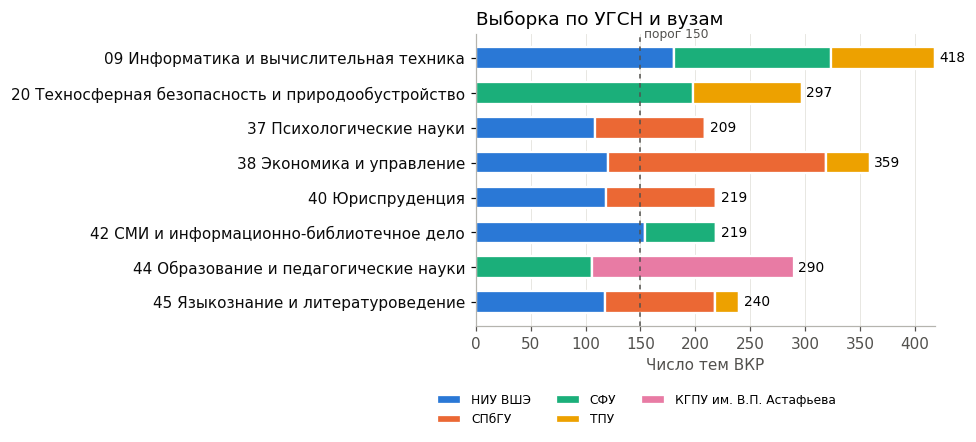

In [4]:
univs = ['НИУ ВШЭ', 'СПбГУ', 'СФУ', 'ТПУ', 'КГПУ им. В.П. Астафьева']
ct = pd.crosstab(df['ugsn'], df['university']).reindex(columns=univs, fill_value=0).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 4.4))
left = np.zeros(len(ct))
for i, u in enumerate(univs):
    ax.barh(ct.index, ct[u], left=left, color=CAT[i], label=u, height=0.62, edgecolor='white', linewidth=1.5)
    left += ct[u].values
for y, total in enumerate(left):
    ax.text(total + 4, y, int(total), va='center', fontsize=9)
ax.axvline(150, color='#52514e', ls=(0, (3, 3)), lw=1)
ax.text(153, len(ct) - 0.4, 'порог 150', fontsize=8, color='#52514e')
ax.set_xlabel('Число тем ВКР')
ax.set_title('Выборка по УГСН и вузам', loc='left', fontsize=12)
ax.legend(ncol=3, fontsize=8, frameon=False, loc='lower center', bbox_to_anchor=(0.35, -0.38))
ax.xaxis.grid(True, color='#e6e5e0', lw=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

In [5]:
pd.crosstab(df['ugsn'], df['year'].replace('', 'н/д'))

year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,н/д
ugsn,,,,,,,,,,,,
09 Информатика и вычислительная техника,0,0,2,21,16,11,7,37,59,177,88,0
20 Техносферная безопасность и природообустройство,24,42,39,37,12,22,50,44,0,12,15,0
37 Психологические науки,0,0,0,0,0,0,25,27,0,157,0,0
38 Экономика и управление,0,0,0,0,8,14,7,11,1,189,129,0
40 Юриспруденция,0,0,0,0,0,0,0,0,0,178,41,0
42 СМИ и информационно-библиотечное дело,0,0,0,0,0,0,0,1,19,170,29,0
44 Образование и педагогические науки,0,0,0,0,0,0,0,40,0,12,54,184
45 Языкознание и литературоведение,3,9,10,0,0,0,0,0,0,118,100,0


> **Ограничение.** У группы 20 много работ 2016–2019 годов: свежих открытых работ по техносферной безопасности мало. У КГПУ год защиты не указан. Выборка неслучайная, цифры описывают эти пять вузов, а не всю страну.

## 4. Лемматизация

Каждое название разбиваем на слова и приводим их к начальной форме через `pymorphy3`.
Частоту считаем **по темам**: если слово дважды встретилось в одном названии, оно учитывается один раз.
Поэтому проценты ниже читаются как «в скольких темах из ста встречается слово».

Слова делим на два списка:
* **рамочные** — описывают тип работы (анализ, разработка, совершенствование, особенность);
* **предметные** — всё остальное.

In [6]:
STOP = set('''и в во на с со к ко по о об обо от до из у за для при через над под про как а но или же ли не ни то это
его ее её их этот эта эти они ооо оао зао пао который которая которые также так чем что где когда между без вне среди
основа пример материал условие случай период вопрос аспект сфера область тип вид часть форма рамка
the of and in a for on to with by an as at from its their is are be using based via'''.split())

FRAME = set('''анализ разработка исследование особенность совершенствование влияние роль оценка проблема применение
использование формирование развитие повышение методика метод подход модель способ система средство фактор механизм
управление организация проектирование создание изучение сравнительный специфика характеристика обеспечение
реализация эффективность возможность перспектива практика процесс деятельность работа направление инструмент
стратегия современный основной правовой теоретический практический новый'''.split())

SHORT_OK = {'ai', 'ml', 'ии', 'it', 'ит', 'vr', 'ar', 'hr', 'pr'}
_cache = {}

def lemma(word):
    w = word.lower()
    if re.match('[a-z]', w):
        return w
    if w not in _cache:
        _cache[w] = morph.parse(w)[0].normal_form
    return _cache[w]

def lemmas(title):
    out = []
    for w in re.findall(r'[A-Za-zА-Яа-яЁё][A-Za-zА-Яа-яЁё\-]+', title):
        l = lemma(w)
        if l in STOP or (len(l) < 3 and l not in SHORT_OK):
            continue
        out.append(l)
    return out

df['lem'] = df['title'].map(lemmas)
df[['title', 'lem']].head(5)

,title,lem
0,Образ Северной Кореи в южнокорейских СМИ: трансформация взглядов в послевоенное время,"[образ, северный, корея, южнокорейский, сми, трансформация, взгляд, послевоенный, время]"
1,Особенности производства и продвижения образовательного медиапродукта в креативных индустриях: на примере онлайн-кур...,"[особенность, производство, продвижение, образовательный, медиапродукт, креативный, индустрия, онлайн-курс, взрослый..."
2,Создание документального фильма,"[создание, документальный, фильм]"
3,Влияние кризиса на репутацию медиабрендов в современной России (на примере глянцевых изданий),"[влияние, кризис, репутация, медиабренд, современный, россия, глянцевый, издание]"
4,Особенности жанра спортивных аниме и манги,"[особенность, жанр, спортивный, аниме, манга]"


## 5. Самые частые слова в целом

In [7]:
def doc_freq(series):
    return collections.Counter(l for ls in series for l in set(ls))

total = doc_freq(df['lem'])
top_all = pd.DataFrame(total.most_common(20), columns=['лемма', 'тем'])
top_all['% тем'] = (top_all['тем'] / len(df) * 100).round(1)
top_all['тип'] = np.where(top_all['лемма'].isin(FRAME), 'рамочное', 'предметное')
top_all

,лемма,тем,% тем,тип
0,разработка,348,15.5,рамочное
1,система,177,7.9,рамочное
2,особенность,157,7.0,рамочное
3,язык,132,5.9,предметное
4,анализ,128,5.7,рамочное
5,российский,120,5.3,предметное
6,развитие,120,5.3,рамочное
7,использование,98,4.4,рамочное
8,управление,92,4.1,рамочное
9,компания,89,4.0,предметное


Верх списка занят словами жанра: «разработка», «система», «особенность», «анализ». Общий словарь ВКР говорит о том, **что студент делает**, а не о чём пишет. Поэтому дальше смотрим на каждую группу отдельно.

## 6. Частоты по группам

In [8]:
DISPLAY = {'совладавать': 'совладающий', 'обучаться': 'обучающийся', 'год': 'год (лет)'}
GROUPS = sorted(df['ugsn'].unique())

def group_words(g, kind='subj', k=15):
    d = df[df['ugsn'] == g]
    cnt = doc_freq(d['lem'])
    keep = (lambda w: w not in FRAME) if kind == 'subj' else (lambda w: w in FRAME)
    rows = [(DISPLAY.get(w, w), c, round(c / len(d) * 100, 1)) for w, c in cnt.most_common() if keep(w)][:k]
    return pd.DataFrame(rows, columns=['лемма', 'тем', '% тем'])

summary = pd.DataFrame({
    g: [', '.join(group_words(g, 'frame', 5)['лемма']), ', '.join(group_words(g, 'subj', 10)['лемма'])]
    for g in GROUPS
}, index=['рамочные (топ-5)', 'предметные (топ-10)']).T
summary

,рамочные (топ-5),предметные (топ-10)
09 Информатика и вычислительная техника,"разработка, система, управление, модель, анализ","приложение, веб-приложение, мобильный, программный, данные, автоматизация, серверный, модуль, сервис, сеть"
20 Техносферная безопасность и природообустройство,"разработка, оценка, система, обеспечение, анализ","мероприятие, безопасность, предприятие, производство, снижение, ситуация, защита, отход, чрезвычайный, риск"
37 Психологические науки,"особенность, фактор, роль, стратегия, использование","психологический, отношение, связь, разный, взаимосвязь, человек, студент, поведение, ребёнок, личностный"
38 Экономика и управление,"анализ, управление, совершенствование, влияние, система","компания, российский, рынок, предприятие, россия, цифровой, финансовый, персонал, китай, государственный"
40 Юриспруденция,"правовой, проблема, практика, использование, особенность","право, регулирование, российский, федерация, россия, объект, ответственность, защита, цифровой, договор"
42 СМИ и информационно-библиотечное дело,"создание, особенность, современный, инструмент, разработка","российский, медиа, бренд, продвижение, проект, россия, сми, репрезентация, авторский, цифровой"
44 Образование и педагогические науки,"развитие, средство, особенность, деятельность, использование","старший, урок, класс, младший, возраст, ребёнок, обучение, обучающийся, язык, дошкольный"
45 Языкознание и литературоведение,"особенность, анализ, исследование, современный, развитие","язык, русский, английский, перевод, языковой, текст, дискурс, русскоязычный, речь, англоязычный"


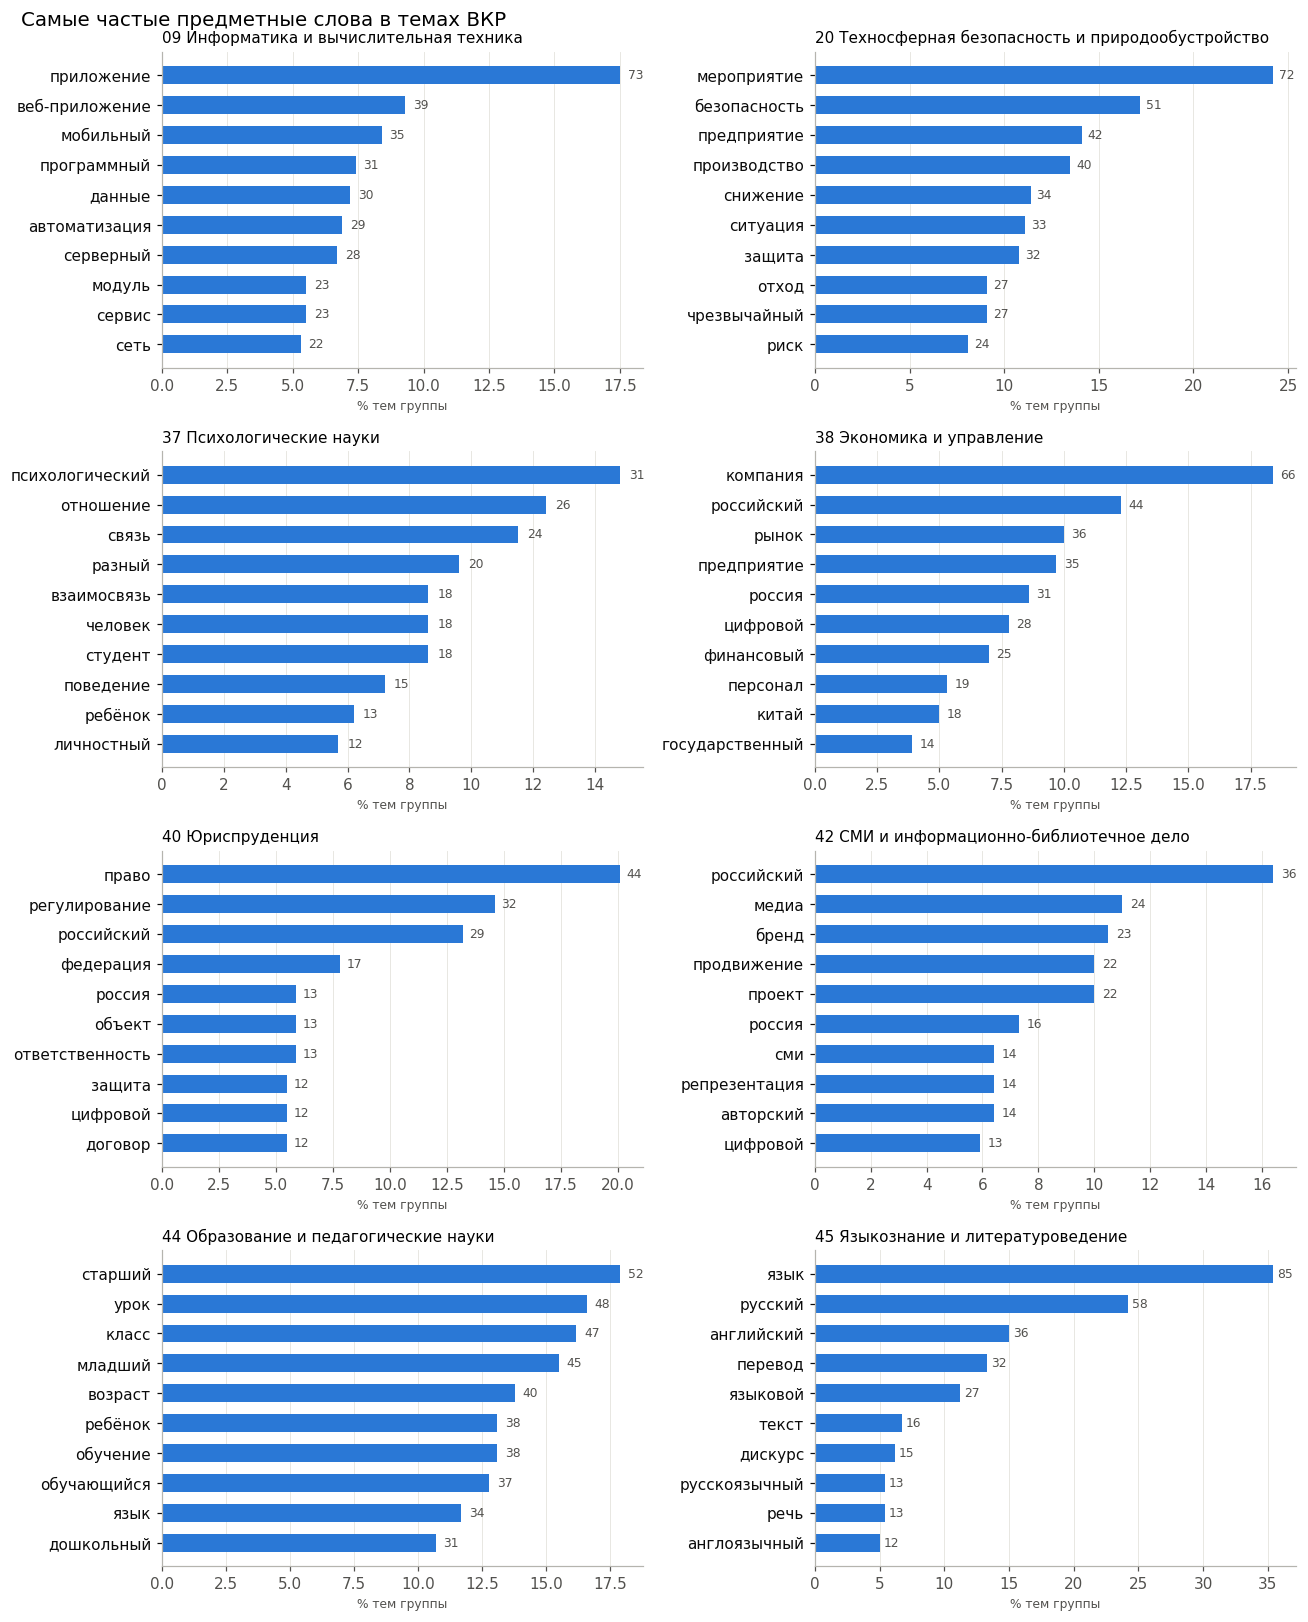

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(12, 15))
for ax, g in zip(axes.flat, GROUPS):
    t = group_words(g, 'subj', 10).iloc[::-1]
    ax.barh(t['лемма'], t['% тем'], color=BLUE, height=0.6)
    for y, (v, c) in enumerate(zip(t['% тем'], t['тем'])):
        ax.text(v + 0.3, y, c, va='center', fontsize=8, color='#52514e')
    ax.set_title(g, loc='left', fontsize=10)
    ax.set_xlabel('% тем группы', fontsize=8)
    ax.xaxis.grid(True, color='#e6e5e0', lw=0.6); ax.set_axisbelow(True)
fig.suptitle('Самые частые предметные слова в темах ВКР', x=0.02, ha='left', fontsize=13)
plt.tight_layout(); plt.show()

### Первое слово темы

Первое слово хорошо показывает жанр, принятый в направлении.

In [10]:
first = (df.assign(first=df['title'].str.split().str[0].str.lower().str.strip('«"'))
           .groupby('ugsn')['first'].apply(lambda s: ', '.join(f'{w} ({c/len(s)*100:.0f}%)' for w, c in s.value_counts().head(4).items())))
first.to_frame('самые частые первые слова')

,самые частые первые слова
ugsn,
09 Информатика и вычислительная техника,"разработка (42%), проектирование (4%), система (4%), веб-приложение (3%)"
20 Техносферная безопасность и природообустройство,"разработка (27%), оценка (11%), мониторинг (6%), анализ (5%)"
37 Психологические науки,"особенности (12%), взаимосвязь (6%), роль (6%), психологические (4%)"
38 Экономика и управление,"совершенствование (9%), влияние (7%), разработка (7%), управление (4%)"
40 Юриспруденция,"правовое (11%), проблемы (5%), правовые (4%), проект (3%)"
42 СМИ и информационно-библиотечное дело,"создание (15%), особенности (6%), разработка (3%), производство (2%)"
44 Образование и педагогические науки,"особенности (12%), методическое (7%), развитие (6%), обучение (6%)"
45 Языкознание и литературоведение,"особенности (6%), разработка (3%), языковые (3%), анализ (2%)"


## 7. Устойчивые словосочетания (биграммы)

In [11]:
def bigrams(g, k=8):
    big = collections.Counter()
    for ls in df.loc[df['ugsn'] == g, 'lem']:
        big.update(set(zip(ls, ls[1:])))
    return ', '.join(f'{a} {b} ({c})' for (a, b), c in big.most_common(k))

pd.DataFrame({'биграммы (число тем)': {g: bigrams(g) for g in GROUPS}})

,биграммы (число тем)
09 Информатика и вычислительная техника,"мобильный приложение (29), система управление (15), разработка система (15), разработка программный (15), проектиров..."
20 Техносферная безопасность и природообустройство,"разработка мероприятие (52), чрезвычайный ситуация (27), мероприятие снижение (19), автоматический установка (17), м..."
37 Психологические науки,"романтический отношение (8), молодой человек (7), социально психологический (5), совладавать поведение (5), человек ..."
38 Экономика и управление,"российский федерация (12), российский компания (10), сравнительный анализ (9), система управление (8), совершенствов..."
40 Юриспруденция,"правовой регулирование (26), российский федерация (17), искусственный интеллект (8), проблема правовой (8), правовой..."
42 СМИ и информационно-библиотечное дело,"авторский проект (8), документальный фильм (6), создание документальный (6), искусственный интеллект (5), социальный..."
44 Образование и педагогические науки,"дошкольный возраст (27), младший школьник (25), старший дошкольный (23), ребёнок старший (21), средство развитие (21..."
45 Языкознание и литературоведение,"английский язык (26), русский язык (25), языковой средство (6), особенность перевод (6), русский английский (5), сло..."


## 8. Какие организации называют в темах

Ищем организационно-правовые формы (ООО, АО, ПАО…) и словарь брендов, СМИ и платформ. Варианты написания сводим вручную.

In [12]:
EXTRA = ['Melon Fashion Group', 'NF Group', 'Дринкит', 'Liman', 'Dr.Spiller', 'Aviasales', 'Т-Банк', 'Кинопоиск',
         'Коммерсант', 'Российской газеты', 'Россия 1', 'Спорт-Экспресс', 'BBC', 'Forbes', 'New York Times', 'Vogue',
         'Евраз', 'Disney', 'Balenciaga', 'Loewe', 'МВД МЕДИА', 'Гараж', 'ТомскСофт', 'Яндекс', 'Telegram', '1С', 'ВТБ',
         'Северсталь', 'YandexGPT', 'Twitch', 'Газпром', 'Dazed', 'Variety', 'WWD', 'Allure', 'МИР']
NORM = [(r'РУСАЛ|Русал', 'РУСАЛ'), (r'Полюс', 'Полюс'), (r'Кр[аА]МЗ', 'КраМЗ'), (r'Сегал', 'ЛПЗ «Сегал»'),
        (r'КЗСК', 'КЗСК'), (r'Красноярский цемент', 'Красноярский цемент'), (r'Газпром', 'Газпром'),
        (r'Ачинский НПЗ', 'Ачинский НПЗ'), (r'Улан-Удэнский авиационный', 'Улан-Удэнский авиазавод'),
        (r'Лесосибирский ЛДК', 'Лесосибирский ЛДК №1'), (r'Мекран', 'Мекран'), (r'Яндекс', 'Яндекс'),
        (r'Российской газеты', 'Российская газета'), (r'Коммерсант', 'Коммерсантъ'), (r'Гараж', 'Музей «Гараж»'),
        (r'^МИР$', 'Платёжная система «Мир»')]
ORGRX = (r'(?:ООО|ПАО|ОАО|ЗАО|АО|ФГУП|МУП|ГУП|МБОУ|МАОУ|МБДОУ|МАДОУ|КГБУ|ФГБУ|ГБУ)\s+'
         r'(?:ЛПЗ\s*|ЦОФ\s*|ПК\s*|Компания\s*)?[«"“]?\s*([^»"”,()]{2,60})')

def companies(t):
    found = {m.group(1).strip(' «"') for m in re.finditer(ORGRX, t)}
    found |= {b for b in EXTRA if re.search(r'(?<![А-Яа-яA-Za-z])' + re.escape(b) + r'(?![a-z])', t)}
    out = set()
    for s in found:
        out.add(next((nm for rx, nm in NORM if re.search(rx, s)), s))
    return sorted(out)

df['companies'] = df['title'].map(companies)
has = df['companies'].map(len) > 0
print(f'Организация названа в {has.sum()} темах из {len(df)} ({has.mean()*100:.1f}%)')
df[has].groupby('ugsn').size().to_frame('тем с организацией')

Организация названа в 127 темах из 2251 (5.6%)


,тем с организацией
ugsn,
09 Информатика и вычислительная техника,21
20 Техносферная безопасность и природообустройство,70
38 Экономика и управление,16
42 СМИ и информационно-библиотечное дело,14
45 Языкознание и литературоведение,6


In [13]:
comp = (df.explode('companies').dropna(subset=['companies'])
          .groupby(['ugsn', 'companies']).size().rename('тем').reset_index()
          .sort_values(['ugsn', 'тем'], ascending=[True, False]))
comp.groupby('ugsn').head(5).reset_index(drop=True)

,ugsn,companies,тем
0,09 Информатика и вычислительная техника,1С,5
1,09 Информатика и вычислительная техника,Telegram,4
2,09 Информатика и вычислительная техника,Яндекс,2
3,09 Информатика и вычислительная техника,Агентство информационных сообщений,1
4,09 Информатика и вычислительная техника,ГЛАВЭКСПЕРТ,1
5,20 Техносферная безопасность и природообустройство,РУСАЛ,9
6,20 Техносферная безопасность и природообустройство,Полюс,7
7,20 Техносферная безопасность и природообустройство,КЗСК,4
8,20 Техносферная безопасность и природообустройство,КраМЗ,4
9,20 Техносферная безопасность и природообустройство,ЛПЗ «Сегал»,4


Компании в темах — редкость. Больше половины упоминаний приходится на техносферную безопасность: там работу пишут на материалах завода, где студент проходил практику.

## 9. Сквозные тематические линии

Маркеры размечены регулярными выражениями по корням слов. Одна тема может попасть в несколько линий.

In [14]:
THEMES = {
 'ИИ, нейросети, ML': r'искусственн\w* интеллект|нейросет|нейронн|машинн\w* обучен|\bLLM\b|\bИИ\b|\bAI\b|языков\w* модел|генератив|ChatGPT|GigaChat|machine learning|компьютерн\w* зрени|\bML\b',
 'Цифровизация, платформы': r'цифров|онлайн|интернет|платформ|маркетплейс|электронн|дистанционн|digital|IT-|ИТ-|кибер',
 'Соцсети, медиа, блогеры': r'социальн\w* сет|соцсет|telegram|телеграм|блог|инфлюенс|youtube|tiktok|вконтакте|подкаст|медиа',
 'Санкции, импортозамещение, кризисы': r'санкц|импортозамещ|ухода? иностран|параллельн\w* импорт|турбулентн|кризис|пандеми|covid|геополит',
 'ESG, устойчивое развитие, экология': r'\bESG\b|устойчив\w* развит|зелен|климат|углерод|экологич|отход|загрязн|декарбониз',
 'Персонал, мотивация, HR': r'персонал|мотивац|кадр|сотрудник|HR|работник|вовлеч|выгоран|трудов\w* коллектив|удержан',
 'Финансы, инвестиции, банки': r'финанс|инвест|банк(?!рот)|кредит|налог|бюджет|страхов|капитал|рентабельн|прибыл|стоимост|облигац|акци[йи]',
 'Безопасность, риски, защита': r'безопасн|пожар|риск|защит|авари|охран\w* труда|травм|угроз',
 'Дети, школьники, студенты, молодёжь': r'дет[ейи]|ребен|школьник|подрост|молод[её]ж|студент|поколени\w* Z|зумер|юност|дошкольн|обучающ',
 'Психическое здоровье, стресс': r'стресс|тревож|выгоран|благополуч|депресс|эмоциональн|копинг|совладающ|самооценк|одиночеств|агресси|удовлетворенност',
 'Государство, регулирование, право': r'правов|законодател|регулирован|государствен|муниципальн|суд|уголовн|гражданск|административн|конституц',
 'Бизнес-стратегия, маркетинг': r'стратег|конкурент|бизнес-модел|рыночн|позиционирован|бренд|продвижен|маркетинг',
 'Китай и Восток': r'Кита|китайск|Азии|азиатск|Япони|японск|Коре|корейск|Индии|индийск|БРИКС|ШОС|Восток',
}
for k, rx in THEMES.items():
    df[k] = df['title'].str.contains(rx, case=False, regex=True)

theme_share = (df.groupby('ugsn')[list(THEMES)].mean().T * 100).round(1)
theme_share = theme_share.loc[theme_share.max(axis=1).sort_values(ascending=False).index]
theme_share

ugsn,09 Информатика и вычислительная техника,20 Техносферная безопасность и природообустройство,37 Психологические науки,38 Экономика и управление,40 Юриспруденция,42 СМИ и информационно-библиотечное дело,44 Образование и педагогические науки,45 Языкознание и литературоведение
"Безопасность, риски, защита",2.2,58.2,4.8,4.2,7.3,1.4,1.0,0.4
"Государство, регулирование, право",0.5,1.0,0.0,6.4,57.1,1.8,1.0,0.4
"Дети, школьники, студенты, молодёжь",3.3,0.0,26.8,2.5,1.4,9.1,56.6,8.3
"Соцсети, медиа, блогеры",2.9,0.0,0.5,1.4,1.4,29.7,0.0,3.3
"Психическое здоровье, стресс",0.5,0.0,24.9,1.4,0.0,0.9,5.2,0.8
"Бизнес-стратегия, маркетинг",1.2,0.0,5.3,16.4,0.0,22.8,0.0,4.2
"Финансы, инвестиции, банки",2.6,0.0,1.4,22.6,12.8,0.9,0.0,0.0
"Цифровизация, платформы",11.0,0.7,7.2,14.2,7.8,16.0,4.1,3.8
"ESG, устойчивое развитие, экология",0.0,14.5,0.5,3.6,2.3,0.5,0.0,0.0
"Персонал, мотивация, HR",3.1,1.7,12.0,11.1,4.1,3.7,1.0,1.7


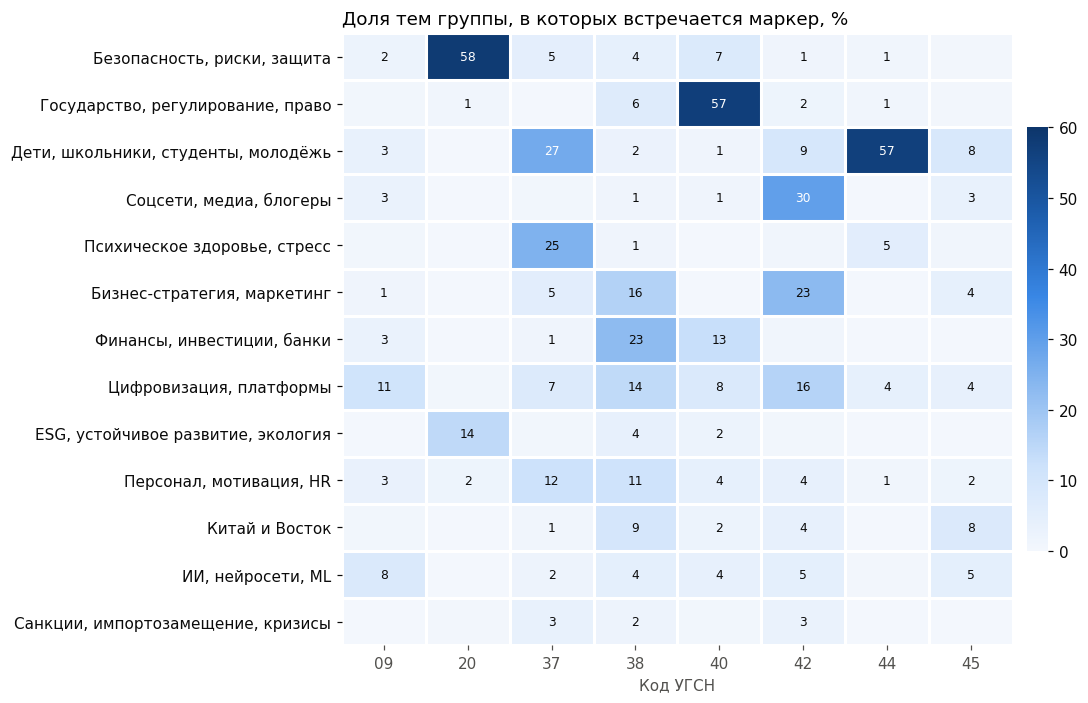

In [15]:
cmap = LinearSegmentedColormap.from_list('b', ['#f3f7fd', '#cde2fb', '#86b6ef', '#3987e5', '#1c5cab', '#0d366b'])
M = theme_share.values
fig, ax = plt.subplots(figsize=(10, 6.5))
im = ax.imshow(M, cmap=cmap, aspect='auto', vmin=0, vmax=60)
ax.set_xticks(range(M.shape[1])); ax.set_xticklabels([c[:2] for c in theme_share.columns])
ax.set_yticks(range(M.shape[0])); ax.set_yticklabels(theme_share.index)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if M[i, j] >= 1:
            ax.text(j, i, f'{M[i, j]:.0f}', ha='center', va='center', fontsize=8,
                    color='white' if M[i, j] >= 25 else '#0b0b0b')
ax.set_xticks(np.arange(-.5, M.shape[1], 1), minor=True); ax.set_yticks(np.arange(-.5, M.shape[0], 1), minor=True)
ax.grid(which='minor', color='white', lw=2); ax.tick_params(which='minor', length=0)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xlabel('Код УГСН')
ax.set_title('Доля тем группы, в которых встречается маркер, %', loc='left', fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02).outline.set_visible(False)
plt.tight_layout(); plt.show()

### Искусственный интеллект: есть ли рост

Сравниваем доли по периодам защиты. Состав вузов в периодах разный, поэтому сравнение приблизительное.

In [16]:
def period(y):
    if not y: return 'н/д'
    y = int(y)
    return '2025–2026' if y >= 2025 else ('2022–2024' if y >= 2022 else 'до 2022')

df['period'] = df['year'].map(period)
ai = df.groupby('period')['ИИ, нейросети, ML'].agg(['sum', 'count', 'mean'])
ai['mean'] = (ai['mean'] * 100).round(1)
ai.rename(columns={'sum': 'тем про ИИ', 'count': 'всего тем', 'mean': '%'})

,тем про ИИ,всего тем,%
period,,,
2022–2024,6,328,1.8
2025–2026,72,1469,4.9
до 2022,5,270,1.9
н/д,0,184,0.0


## 10. Насколько работы прикладные

По названию можно оценить только намерение. Считаем три признака.

In [17]:
df['проектная формулировка'] = df['title'].str.contains(
    r'разработк|проектирован|создани|внедрени|рекомендаци|совершенствован|программ[аы] |методик|сервис|приложени|'
    r'платформ|систем[аы] |модел|прототип|бизнес-план|проект', case=False, regex=True)
df['названа организация или её тип'] = df['title'].str.contains(
    r'ООО|ПАО|АО |ОАО|ЗАО|МБОУ|МАОУ|МБДОУ|МАДОУ|предприяти|компани|организаци|банк(?!рот)|завод|корпорац|холдинг', regex=True)
df['«на примере / на материале»'] = df['title'].str.contains(r'на примере|на материале|кейс', case=False, regex=True)

applied_cols = ['проектная формулировка', 'названа организация или её тип', '«на примере / на материале»']
applied = (df.groupby('ugsn')[applied_cols].mean() * 100).round(1)
applied

,проектная формулировка,названа организация или её тип,«на примере / на материале»
ugsn,,,
09 Информатика и вычислительная техника,80.9,7.7,0.7
20 Техносферная безопасность и природообустройство,47.8,39.1,3.0
37 Психологические науки,4.8,3.8,1.0
38 Экономика и управление,33.4,37.6,4.7
40 Юриспруденция,7.8,6.4,1.8
42 СМИ и информационно-библиотечное дело,39.3,3.7,13.2
44 Образование и педагогические науки,12.1,4.5,4.5
45 Языкознание и литературоведение,10.0,1.2,21.7


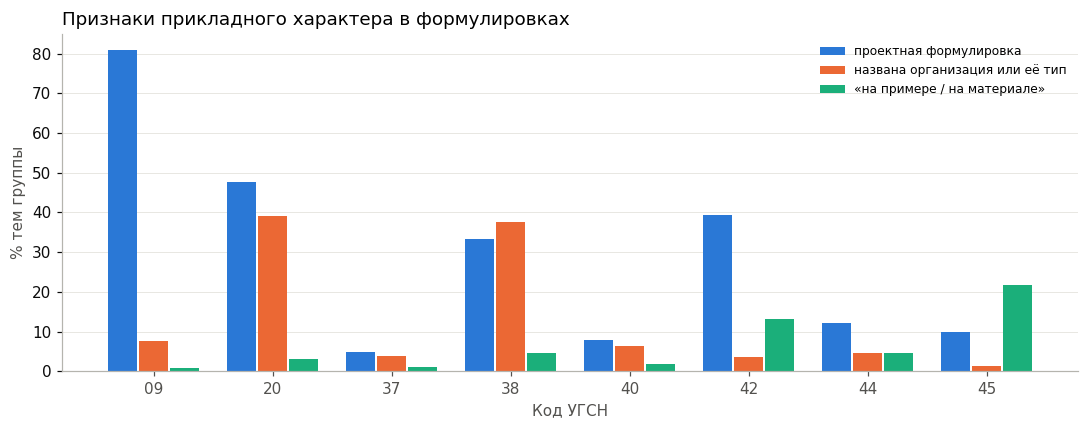

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(applied)); w = 0.26
for i, col in enumerate(applied_cols):
    ax.bar(x + (i - 1) * w, applied[col], w * 0.92, color=CAT[i], label=col)
ax.set_xticks(x); ax.set_xticklabels([g[:2] for g in applied.index])
ax.set_ylabel('% тем группы'); ax.set_xlabel('Код УГСН')
ax.set_title('Признаки прикладного характера в формулировках', loc='left', fontsize=12)
ax.legend(fontsize=8, frameon=False)
ax.yaxis.grid(True, color='#e6e5e0', lw=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

Дополнительно вручную проверены аннотации 762 работ СПбГУ и ТПУ: прямых упоминаний внедрения («акт о внедрении», «апробировано», «принято к использованию») нет ни в одной. Практическую значимость заявляют от 1 до 15% работ в зависимости от группы. Открытые метаданные на вопрос «где опробовали результаты» ответа не дают.

По данным Минобрнауки, в 2025 году в формате «Стартап как диплом» 5180 студентов защитили 3260 ВКР в 204 вузах ([Известия, 04.06.2026](https://iz.ru/2108334/2026-06-04/minobrnauki-nazvalo-kolichestvo-vypusknikov-vuzov-so-startapami)).

## 11. Примеры тем

In [19]:
df.groupby('ugsn').sample(3, random_state=11)[['ugsn', 'university', 'title']].reset_index(drop=True)

,ugsn,university,title
0,09 Информатика и вычислительная техника,СФУ,Система «Умный дом» для коттеджного строения
1,09 Информатика и вычислительная техника,ТПУ,Параметризация микрофизических свойств кристаллического облака для расчета ослабления лучистой энергии
2,09 Информатика и вычислительная техника,ТПУ,Разработка интерактивной виртуальной сцены для обучения особенностям вождения на гоночных трассах
3,20 Техносферная безопасность и природообустройство,ТПУ,Повышение эффективности системы пожарной защиты торгового предприятия в г. Чолпон-Ата Республики Кыргызстан
4,20 Техносферная безопасность и природообустройство,СФУ,Усовершенствование работы адсорбционной системы с целью снижения сбросов углеводородов подаваемых на термообезврежив...
5,20 Техносферная безопасность и природообустройство,СФУ,Разработка систем вентиляции на производстве метизной продукции
6,37 Психологические науки,НИУ ВШЭ,Концептуализация внутреннего критика у студентов в рамках парадигмы IFS терапии
7,37 Психологические науки,СПбГУ,"Особенности психологического функционирования и отношения к ребенку у беременных женщин, использовавших вспомогатель..."
8,37 Психологические науки,СПбГУ,"Особенности ценностно-мотивационной сферы молодежи, получающей среднее профессиональное и высшее образование"
9,38 Экономика и управление,ТПУ,Организация продажи продуктов питания через интернет


## 12. Выводы

1. **Темы различаются прежде всего жанром.** В ИТ 42% тем начинаются со слова «разработка», у психологов первые слова — «особенности» и «взаимосвязь», у юристов — «правовое регулирование», у журналистов — «создание».
2. **Предметно студентов занимают четыре вещи:** люди и отношения (психология, педагогика), цифровая среда и её регулирование (право, медиа, ИТ), деньги и управление (экономика), безопасность производства (техносферная безопасность).
3. **ИИ растёт, но пока небольшая тема:** около 5% работ 2025–2026 годов против 2% в более ранних. Тема есть в семи группах из восьми.
4. **Азиатский поворот заметен:** Китай встречается в 9% экономических тем и 8% лингвистических.
5. **Компании в названиях — редкость (5,6% тем).** Чаще всего это заводы региона, где студент проходил практику.
6. **Внедрение результатов по открытым данным не подтверждается.** В карточках ВКР стоит публиковать поле «внедрение / апробация».

**Как развить:** добавить вузы других типов, собрать данные за 2019–2026 годы по одним и тем же программам, разобрать аннотации всех работ.